In [10]:
# importaciones
import pandas as pd
import matplotlib.pyplot as plt

# 1. No limitar el número de columnas al mostrar
pd.set_option('display.max_columns', None)

# 2. No saltar de línea aunque la tabla sea muy ancha
pd.set_option('display.expand_frame_repr', False)

# 3. Esto hace que las gráficas se vean más modernas
plt.style.use('ggplot')

print('Toda las importaciones funciono')

Toda las importaciones funciono


In [ ]:
# Cargar datos
df = pd.read_csv('SpotifyFeatures.csv')
print(df)

# Usamos .copy() al final para que sea un objeto totalmente independiente y .dropna() para eliminar las columnas con campos con Null
df_limpio = df.dropna().copy()

# Reajustas los índices (opcional pero recomendado)
df_limpio = df_limpio.reset_index(drop=True)

#  Cantidad de filas con registros antes de limpiar
print(f"Filas originales: {len(df)}")

#  Cantidad de filas con registros despues de limpiar
print(f"Filas después de limpiar: {len(df_limpio)}")

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
208285,World,Elevation Worship,NaN,7BGQCe62A58Q5ZgpQFX93t,44,0.019,0.287,350027,0.446,0.0,F,0.1,-7.214,Major,0.0317,138.727,4/4,0.0387


In [14]:
# ¿Qué géneros tienen mayor popularidad?
top_genres = df_limpio.groupby('genre')['popularity'].agg(['mean', 'count']).sort_values('mean', ascending=False).head(5)
print(top_genres)
# En conclusión los generos con más popularidad son:
# 1. pop
# 2. rap
# 3. rock
# 4. hip-pop
# 5. dance

              mean  count
genre                    
Pop      66.590667   9386
Rap      60.533795   9232
Rock     59.619392   9272
Hip-Hop  58.423131   9295
Dance    57.275256   8701


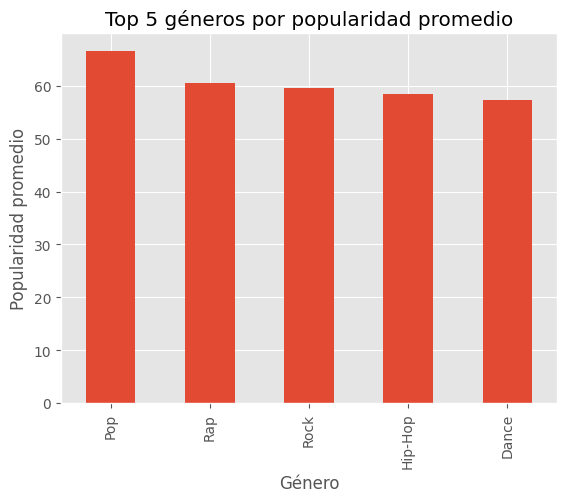

In [ ]:
top_genres['mean'].plot(kind='bar')

plt.title('Top 5 géneros por popularidad promedio')
plt.xlabel('Género')
plt.ylabel('Popularidad promedio')
plt.xticks(rotation=45)
# plt.tight_layout()
plt.show()

In [4]:
# ¿Qué características influyen en la popularidad?
# select_dtypes filtra las columnas, para que solo sea numericas y luego lo guarda en la variable numericas
numericas = df_limpio.select_dtypes(include='number')
# Mirar que columnas despues de filtrar
# numericas.columns
# Calcula todas las correlaciones entre todas las variables númericas
numericas.corr()['popularity'].sort_values(ascending=False).head()

popularity      1.000000
loudness        0.363011
danceability    0.256567
energy          0.248922
tempo           0.081039
Name: popularity, dtype: float64

La popularidad presenta una distribución moderada, con mayor concentración en valores medios (entre 30 y 60). No está completamente concentrada en un solo rango, pero tampoco distribuida de forma uniforme, ya que existen menos canciones con popularidad muy alta.


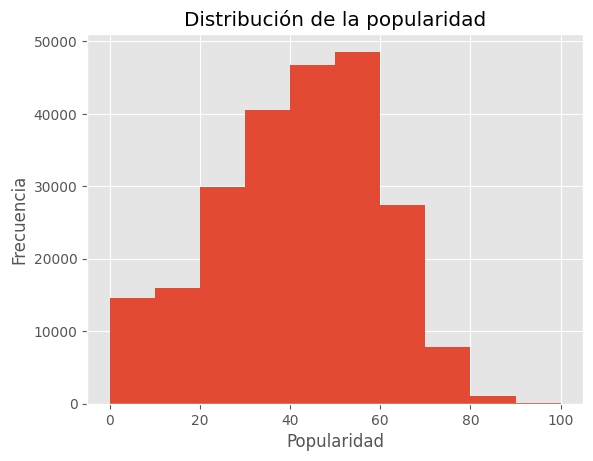

In [5]:
# ¿La popularidad está concentrada o distribuida?
print('La popularidad presenta una distribución moderada, con mayor concentración en valores medios (entre 30 y 60). No está completamente concentrada en un solo rango, pero tampoco distribuida de forma uniforme, ya que existen menos canciones con popularidad muy alta.')

df_limpio['popularity'].hist()

plt.title('Distribución de la popularidad')
plt.xlabel('Popularidad')
plt.ylabel('Frecuencia')
plt.show()

In [43]:
# ¿Qué tipo de música debería recomendar el sistema?
print("Según el análisis de los datos, los géneros con mayor popularidad promedio son pop, rap, rock y hip-hop. Además, las características que más se correlacionan con la popularidad son loudness, danceability, energy y tempo. Por lo tanto, el sistema debería priorizar canciones de estos géneros que presenten altos valores en dichas características.")

Según el análisis de los datos, los géneros con mayor popularidad promedio son pop, rap, rock y hip-hop. Además, las características que más se correlacionan con la popularidad son loudness, danceability, energy y tempo. Por lo tanto, el sistema debería priorizar canciones de estos géneros que presenten altos valores en dichas características.


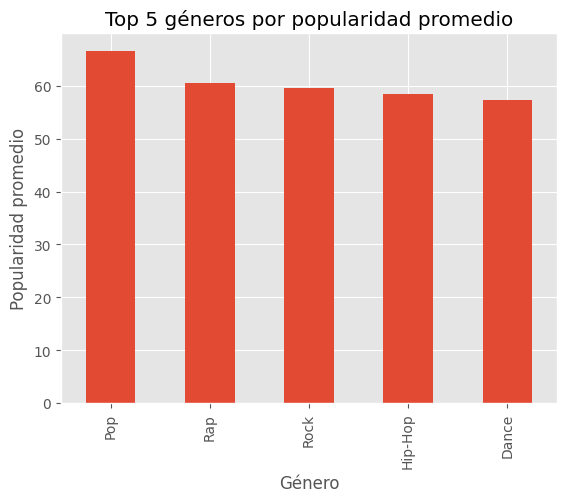

In [6]:
# Generos
top_generos = df_limpio.groupby('genre')['popularity'].mean() \
    .sort_values(ascending=False) \
    .head(5)

top_generos.plot(kind='bar')

plt.title('Top 5 géneros por popularidad promedio')
plt.xlabel('Género')
plt.ylabel('Popularidad promedio')
plt.show()

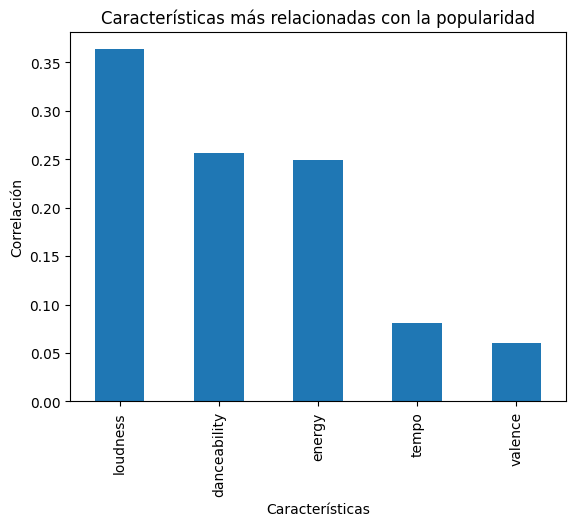

In [45]:
# Caracteristicas vs popularidad
corr = df_limpio.select_dtypes(include='number').corr()['popularity'] \
    .drop('popularity') \
    .sort_values(ascending=False)

corr.head(5).plot(kind='bar')

plt.title('Características más relacionadas con la popularidad')
plt.xlabel('Características')
plt.ylabel('Correlación')
plt.show()